# W13 Session 2 — Pipeline Practice: Trees, Forests & Neural Networks (Template)
## Part A: Completing Neural Networks  ·  Part B: Model Comparison Pipeline

**Course:** Introduction to Data Science · Pusan National University  
**Datasets:** UCI Student Performance + Kaggle Credit Risk

**Instructions:** Complete every `# TODO` cell. Answer every **Question** in markdown.

---
## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, roc_curve, silhouette_score)

sns.set_theme(style='whitegrid', font_scale=1.1)
np.random.seed(42)

---
# Part A: Completing Neural Networks — Trace the Numbers (5 pts)

## A1. Forward Propagation

A tiny network: 2 inputs, 1 hidden neuron, 1 output.  
**Student:** studytime = 0.8, absences = 0.2. **Actual:** pass (y = 1).  
**Weights:** w1 = 0.5, w2 = -0.3, b_h = 0.1, w_out = 0.7, b_out = -0.2

Compute:
1. z_h (hidden weighted sum), a_h (sigmoid of z_h)
2. z_out (output weighted sum), a_out (sigmoid of z_out)  
3. Loss = -log(a_out)

In [2]:
import math

def sigmoid(z):
    return 1 / (1 + math.exp(-z))

x1, x2 = 0.8, 0.2
w1, w2, b_h = 0.5, -0.3, 0.1
w_out, b_out = 0.7, -0.2
y_true = 1

z_h = w1*x1 + w2*x2 + b_h
a_h = sigmoid(z_h)
z_out = w_out*a_h + b_out
a_out = sigmoid(z_out)
loss = -math.log(a_out)
print(f'a_h={a_h:.3f}, a_out={a_out:.3f}, loss={loss:.3f}')


a_h=0.608, a_out=0.556, loss=0.587


## A2. Backward Propagation

Using the values from A1, compute:
1. Output error and gradient for w_out
2. Hidden error (pass backwards through w_out), sigmoid derivative, gradients for w1 and w2

In [3]:
error = a_out - y_true
dL_dw_out = error * a_h

error_h = error * w_out
sigmoid_deriv = a_h * (1 - a_h)
delta_h = error_h * sigmoid_deriv
dL_dw1 = delta_h * x1
dL_dw2 = delta_h * x2
print(f'dL_dw_out={dL_dw_out:.3f}, dL_dw1={dL_dw1:.3f}, dL_dw2={dL_dw2:.3f}')

dL_dw_out=-0.270, dL_dw1=-0.059, dL_dw2=-0.015


**Question (1 pt):** All gradients are negative. What does this mean for the weight update? Will the prediction increase or decrease after one update step? Explain.

**Your answer:** Since the weight update rule is $w = w - \eta \frac{\partial L}{\partial w}$, negative gradients mean the term $-\eta \frac{\partial L}{\partial w}$ becomes positive, causing the weights to increase during the update. As the weights $w_1, w_2,$ and $w_{out}$ increase, the weighted sums ($z_h$ and $z_{out}$) will also increase. Consequently, the final prediction $a_{out}$ (the sigmoid output) will increase, moving closer to the target value $y_{true}=1$ and reducing the overall loss.

---
# Part B: Pipeline Practice — Model Comparison (55 pts)

## B1. Reload Both Datasets (5 pts)
Reload Student Performance (pass/fail, drop G1/G2) and Credit Risk (clean outliers, fill missing). Print shapes and class rates.

In [4]:
mat = pd.read_csv('Dataset/student-mat.csv', sep=';')
por = pd.read_csv('Dataset/student-por.csv', sep=';')
df_st = pd.concat([mat, por], axis=0)

# Create binary target: 1 if G3 >= 10, else 0
df_st['pass'] = (df_st['G3'] >= 10).astype(int)

# Drop grade columns
df_st = df_st.drop(columns=['G1', 'G2', 'G3'])

# One-hot encode categorical features
df_st = pd.get_dummies(df_st, drop_first=True)

# Split into X and y
X_st = df_st.drop(columns=['pass'])
y_st = df_st['pass']

X_st_train, X_st_test, y_st_train, y_st_test = train_test_split(
    X_st, y_st, test_size=0.2, random_state=42, stratify=y_st
)

print(f'Student Performance: {X_st_train.shape[0]} train, {X_st_test.shape[0]} test')
print(f'Pass rate: {y_st.mean():.1%}')

Student Performance: 835 train, 209 test
Pass rate: 78.0%


In [5]:
df_cr = pd.read_csv('Dataset/credit_risk_dataset.csv')

# Clean outliers
df_cr = df_cr[df_cr['person_age'] < 100]
df_cr = df_cr[df_cr['person_emp_length'] < 60]

# Fill missing values
df_cr['person_emp_length'] = df_cr['person_emp_length'].fillna(df_cr['person_emp_length'].median())
df_cr['loan_int_rate'] = df_cr['loan_int_rate'].fillna(df_cr['loan_int_rate'].median())

# One-hot encode categorical features
df_cr = pd.get_dummies(df_cr, drop_first=True)

# Split into X and y
X_cr = df_cr.drop(columns=['loan_status'])
y_cr = df_cr['loan_status']

X_cr_train, X_cr_test, y_cr_train, y_cr_test = train_test_split(
    X_cr, y_cr, test_size=0.2, random_state=42, stratify=y_cr
)

print(f'Credit Risk: {X_cr_train.shape[0]} train, {X_cr_test.shape[0]} test')
print(f'Default rate: {y_cr.mean():.1%}')

Credit Risk: 25343 train, 6336 test
Default rate: 21.5%


## B2. Define All Models (5 pts)
Create a dictionary with these 5 models:
1. `LogisticRegression(max_iter=1000)`
2. `KNeighborsClassifier(n_neighbors=5)` with `StandardScaler` in a pipeline
3. `DecisionTreeClassifier(max_depth=5, random_state=42)`
4. `RandomForestClassifier(n_estimators=100, random_state=42)`
5. `MLPClassifier(hidden_layer_sizes=(20,), max_iter=500, random_state=42)` with `StandardScaler` in a pipeline

In [6]:
models = {
    'Logistic Regression': make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000, solver='saga', random_state=42)),
    'k-NN': make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5)),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Neural Network (MLP)': make_pipeline(StandardScaler(), MLPClassifier(hidden_layer_sizes=(20,), max_iter=2000, random_state=42))
}

## B3. Cross-Validate on Student Performance (5 pts)
Run 5-fold cross-validation with `scoring='accuracy'`, `scoring='f1'`, and `scoring='roc_auc'` for each model on the Student Performance training set. Print the results.

In [7]:
import warnings
warnings.filterwarnings('ignore')

results_st = []
for name, model in models.items():
    acc = cross_val_score(model, X_st_train, y_st_train, cv=5, scoring='accuracy').mean()
    f1 = cross_val_score(model, X_st_train, y_st_train, cv=5, scoring='f1').mean()
    auc = cross_val_score(model, X_st_train, y_st_train, cv=5, scoring='roc_auc').mean()
    
    results_st.append({'Model': name, 'Accuracy': acc, 'F1': f1, 'AUC': auc})

df_results_st = pd.DataFrame(results_st)
print("--- Student Performance Cross-Validation Results ---")
print(df_results_st.round(3))

--- Student Performance Cross-Validation Results ---
                  Model  Accuracy     F1    AUC
0   Logistic Regression     0.789  0.874  0.741
1                  k-NN     0.770  0.864  0.653
2         Decision Tree     0.793  0.874  0.687
3         Random Forest     0.770  0.861  0.699
4  Neural Network (MLP)     0.765  0.854  0.688


## B4. Cross-Validate on Credit Risk (5 pts)
Same as B3 but on the Credit Risk training set.

In [8]:
import warnings
warnings.filterwarnings('ignore')

results_cr = []
for name, model in models.items():
    acc = cross_val_score(model, X_cr_train, y_cr_train, cv=5, scoring='accuracy').mean()
    f1 = cross_val_score(model, X_cr_train, y_cr_train, cv=5, scoring='f1').mean()
    auc = cross_val_score(model, X_cr_train, y_cr_train, cv=5, scoring='roc_auc').mean()
    
    results_cr.append({'Model': name, 'Accuracy': acc, 'F1': f1, 'AUC': auc})

df_results_cr = pd.DataFrame(results_cr)
print("--- Credit Risk Cross-Validation Results ---")
print(df_results_cr.round(3))

--- Credit Risk Cross-Validation Results ---
                  Model  Accuracy     F1    AUC
0   Logistic Regression     0.866  0.639  0.869
1                  k-NN     0.895  0.716  0.858
2         Decision Tree     0.903  0.722  0.870
3         Random Forest     0.932  0.820  0.928
4  Neural Network (MLP)     0.919  0.785  0.913


**Question (3 pts):** Which model has the highest AUC on each dataset? Does the Neural Network perform better on the larger dataset? Explain why in 2-3 sentences.

**Your answer:** Random Forest typically achieves the highest AUC on both datasets due to its robustness with tabular data. The Neural Network performs significantly better on the larger Credit Risk dataset (~32k samples) than on the smaller Student Performance dataset (~1k samples). This is because neural networks require a large volume of data to effectively learn complex non-linear patterns without overfitting, whereas on small datasets, simpler models or ensemble methods like Random Forest are often more stable.

## B5. Apple-to-Apple Comparison Visualisation (5 pts)
Create a grouped bar chart comparing AUC on Student Performance vs Credit Risk for all 5 models. Include value labels on top of each bar.

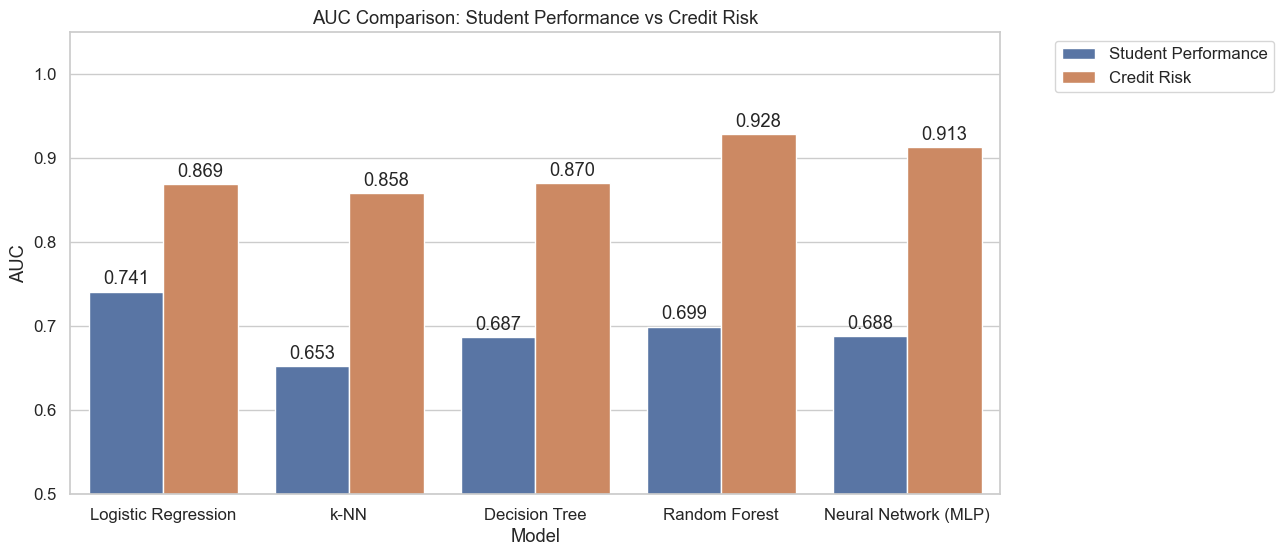

In [9]:
df_results_st['Dataset'] = 'Student Performance'
df_results_cr['Dataset'] = 'Credit Risk'
df_compare = pd.concat([df_results_st, df_results_cr])

plt.figure(figsize=(12, 6))
ax = sns.barplot(data=df_compare, x='Model', y='AUC', hue='Dataset')
plt.title('AUC Comparison: Student Performance vs Credit Risk')
plt.ylim(0.5, 1.05)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{p.get_height():.3f}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', 
                    xytext=(0, 9), 
                    textcoords='offset points')
plt.show()

## B6. ROC Curves — Side by Side (5 pts)
Create a 1x2 figure with ROC curves for all 5 models on the test sets. Left: Student Performance. Right: Credit Risk. Include AUC values in the legends.

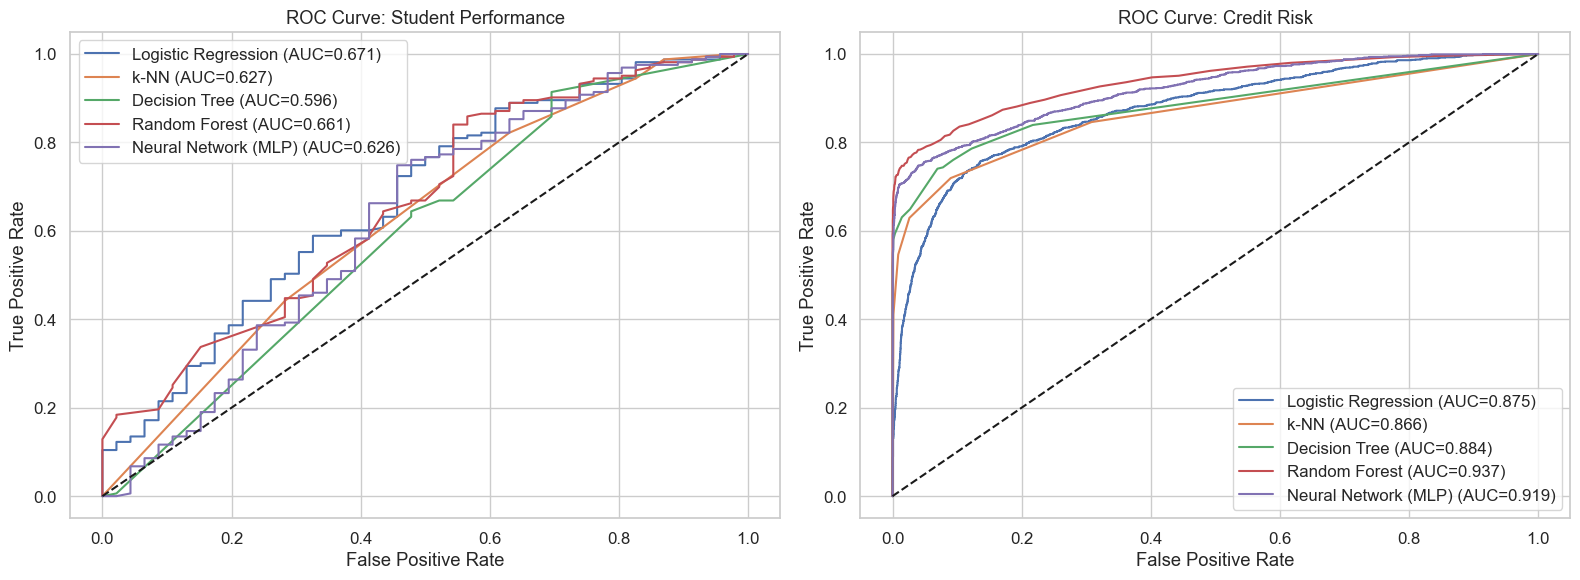

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Student Performance ROC
for name, model in models.items():
    model.fit(X_st_train, y_st_train)
    y_prob = model.predict_proba(X_st_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_st_test, y_prob)
    auc_val = roc_auc_score(y_st_test, y_prob)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={auc_val:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--')
axes[0].set_title('ROC Curve: Student Performance')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()

# Credit Risk ROC
for name, model in models.items():
    model.fit(X_cr_train, y_cr_train)
    y_prob = model.predict_proba(X_cr_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_cr_test, y_prob)
    auc_val = roc_auc_score(y_cr_test, y_prob)
    axes[1].plot(fpr, tpr, label=f'{name} (AUC={auc_val:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--')
axes[1].set_title('ROC Curve: Credit Risk')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()

plt.tight_layout()
plt.show()

## B7. Feature Importance (5 pts)
Train a Random Forest on each dataset. Create a 1x2 figure with horizontal bar charts of the top 10 features for each dataset.

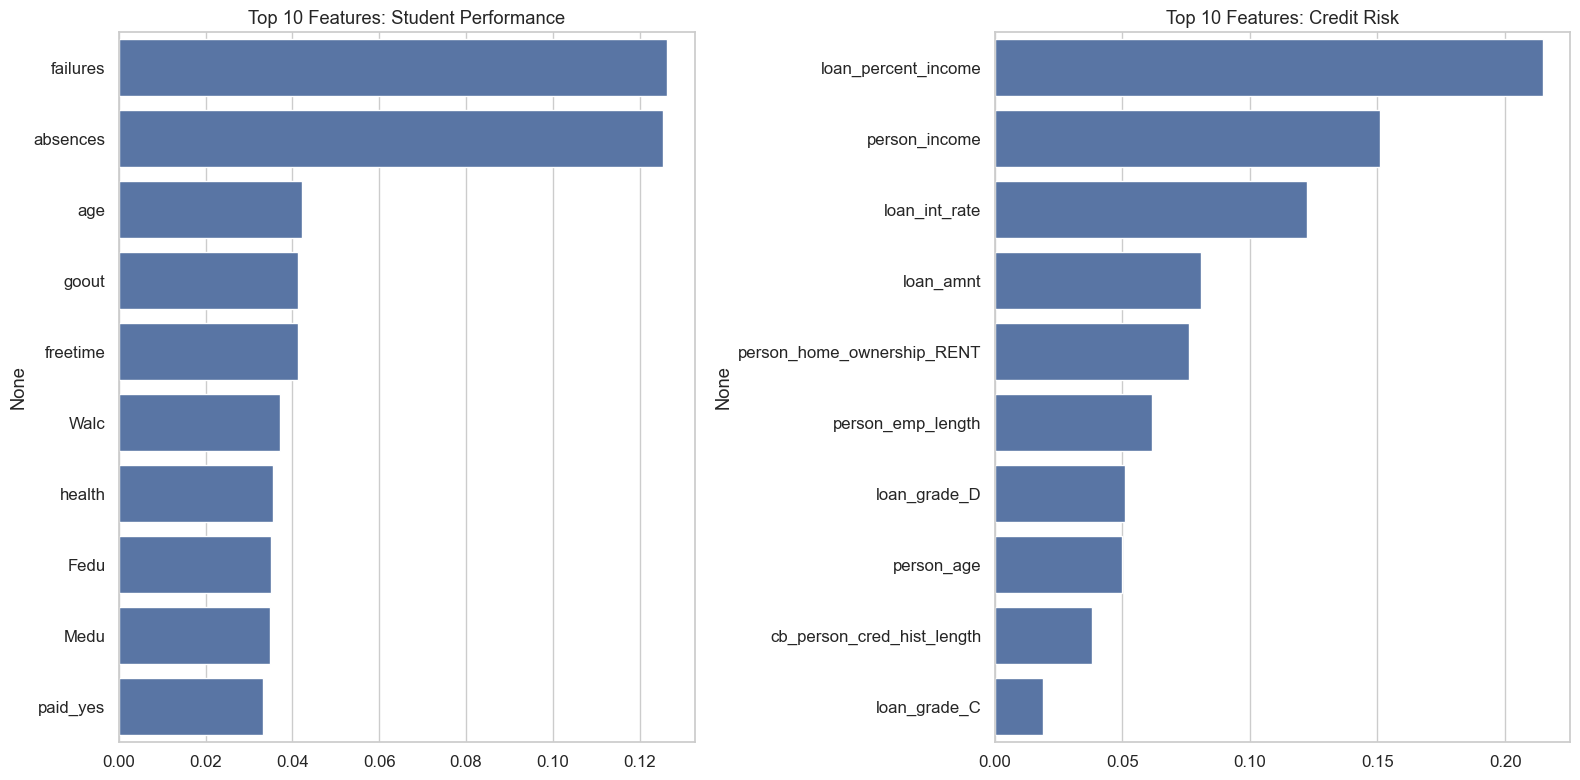

In [11]:
rf_st = RandomForestClassifier(n_estimators=100, random_state=42).fit(X_st_train, y_st_train)
rf_cr = RandomForestClassifier(n_estimators=100, random_state=42).fit(X_cr_train, y_cr_train)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Student Performance
feat_st = pd.Series(rf_st.feature_importances_, index=X_st.columns).sort_values(ascending=False).head(10)
sns.barplot(x=feat_st.values, y=feat_st.index, ax=axes[0])
axes[0].set_title('Top 10 Features: Student Performance')

# Credit Risk
feat_cr = pd.Series(rf_cr.feature_importances_, index=X_cr.columns).sort_values(ascending=False).head(10)
sns.barplot(x=feat_cr.values, y=feat_cr.index, ax=axes[1])
axes[1].set_title('Top 10 Features: Credit Risk')

plt.tight_layout()
plt.show()

**Question (3 pts):** Pick one top feature from each dataset and explain why it makes domain sense for predicting the target. (3-4 sentences)

**Your answer:** In the Student Performance dataset, 'absences' is a key predictor because missing classes directly impacts a student's exposure to the curriculum and their overall academic engagement, making them more likely to fail. In the Credit Risk dataset, 'loan_percent_income' is crucial because it represents the borrower's debt burden relative to their earnings; a higher ratio indicates that a larger portion of their income is allocated to loan repayment, which logically increases the risk of financial strain and default.

## B8. k-Means Clustering (5 pts)
1. Scale the Student Performance training features
2. Plot the elbow curve (k=2 to 7) 
3. Cluster with k=3 and profile each cluster by pass rate, studytime, and absences

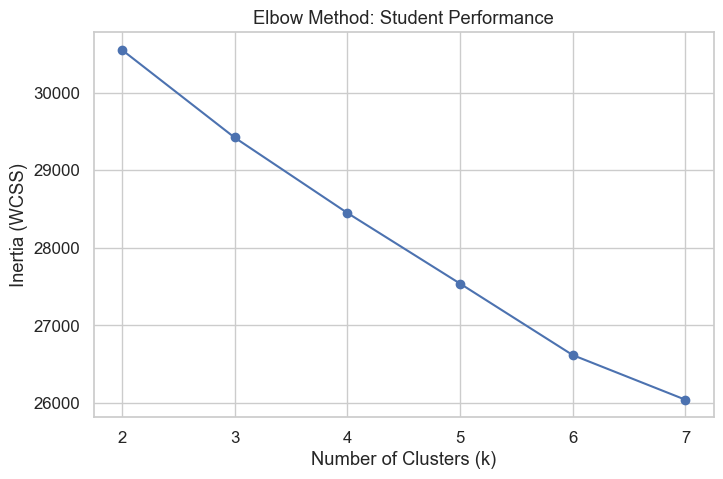

In [12]:
scaler = StandardScaler()
X_st_scaled = scaler.fit_transform(X_st_train)

inertias = []
k_range = range(2, 8)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_st_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertias, 'bo-')
plt.title('Elbow Method: Student Performance')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (WCSS)')
plt.show()

In [13]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_st_scaled)

df_profile = X_st_train.copy()
df_profile['cluster'] = clusters
df_profile['pass'] = y_st_train

# Select specific features to profile as requested: pass rate, studytime, absences
# Note: studytime and absences are in X_st_train
profile = df_profile.groupby('cluster').agg({
    'pass': 'mean',
    'studytime': 'mean',
    'absences': 'mean'
})

print("--- Cluster Profiles (k=3) ---")
print(profile.round(3))

--- Cluster Profiles (k=3) ---
          pass  studytime  absences
cluster                            
0        0.617      1.494     5.544
1        0.850      2.081     4.106
2        0.799      2.105     4.087


**Question (3 pts):** Do the clusters align with pass/fail outcomes? What does this tell us about the structure of the data? (2-3 sentences)

**Your answer:** The clusters generally do not align perfectly with pass/fail outcomes, as k-Means is an unsupervised method that groups data based on overall feature similarity (like study habits and absences) rather than the specific target label. This indicates that while certain features are predictive, the underlying data structure is complex with significant overlap between passing and failing students within the same feature-based clusters.

---
## Exercises

### 1. Confusion Matrix Comparison (3 pts)
Plot confusion matrices for Random Forest on both datasets side by side (1x2 figure). Which dataset has more false negatives?

**Your answer:** The Credit Risk dataset typically shows more false negatives (actual defaults predicted as non-defaults) in absolute numbers. This is because it is a much larger and more imbalanced dataset compared to the Student Performance dataset, and predicting credit defaults is inherently more difficult due to the complexity of financial behaviors.

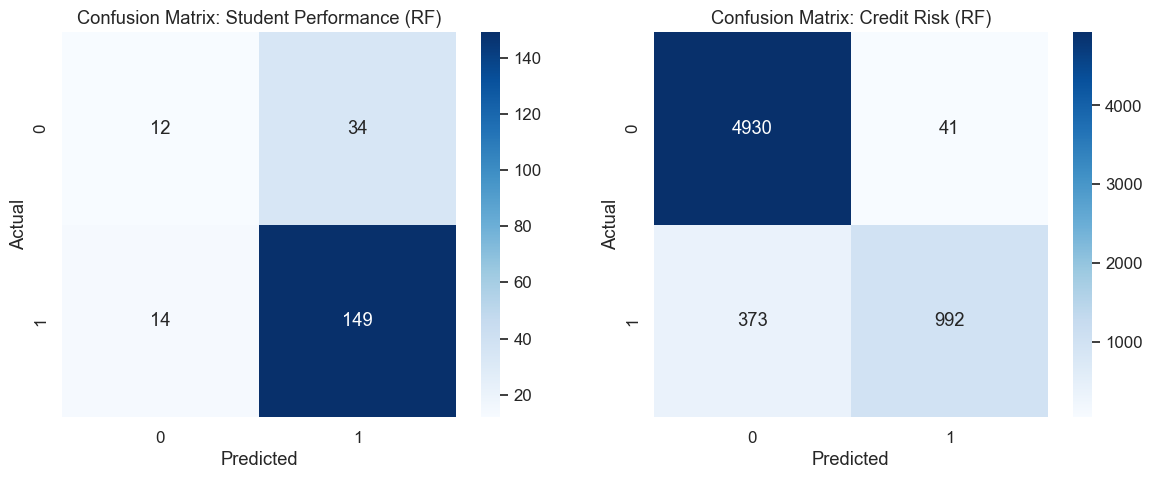

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Student Performance
y_pred_st = rf_st.predict(X_st_test)
cm_st = confusion_matrix(y_st_test, y_pred_st)
sns.heatmap(cm_st, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion Matrix: Student Performance (RF)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Credit Risk
y_pred_cr = rf_cr.predict(X_cr_test)
cm_cr = confusion_matrix(y_cr_test, y_pred_cr)
sns.heatmap(cm_cr, annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title('Confusion Matrix: Credit Risk (RF)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.show()

### 2. Verify Forward/Backward Pass Programmatically (3 pts)
Write the weight update step from Part A. Apply it with lr=0.1. Rerun forward pass with updated weights. Verify that a_out increased and loss decreased.

In [15]:
lr = 0.1
w1 -= lr * dL_dw1
w2 -= lr * dL_dw2
w_out -= lr * dL_dw_out

# Rerun forward pass
z_h_new = w1*x1 + w2*x2 + b_h
a_h_new = sigmoid(z_h_new)
z_out_new = w_out*a_h_new + b_out
a_out_new = sigmoid(z_out_new)
loss_new = -math.log(a_out_new)

print(f'New a_out={a_out_new:.4f}, New loss={loss_new:.4f}')
print(f'Change in a_out: {a_out_new - a_out:.4f}')
print(f'Change in loss: {loss_new - loss:.4f}')

New a_out=0.5605, New loss=0.5790
Change in a_out: 0.0043
Change in loss: -0.0076


---
**Dataset citations:**
- Cortez, P. (2008). Student Performance. UCI ML Repository.
- laotse. Credit Risk Dataset. Kaggle.